## 03 — Point-source sweeps with random **continuous** locations

This notebook keeps the 02 pipeline (grid → operator → GMRES), but varies the RHS over:
- random **integer-index** point sources (baseline), and
- random **continuous (x,y)** point sources with **bilinear deposit** (finer coverage).

Goals:
- keep the notebook minimal (no new helper functions here),
- assemble the operator once,
- run small batches and preview convergence and one example field.
"""


### 1. Setup and physical idea

We consider the Helmholtz equation

\[
(\nabla^2 + k^2) u = f
\]

where:
- \(u(x, y)\) is the complex-valued wave field we solve for,  
- \(k\) is the wavenumber, controlling oscillation frequency, and  
- \(f(x, y)\) is the **source term**.

By changing \(f\), we effectively move the *excitation* (the "sound source" or "light bulb")
around the domain.

In this notebook we fix the grid and operator \(A\), and only change the right-hand side \(b\).
Each run answers the question:
> "What does the field look like if the source appears **here**, with this **phase** and **amplitude**?"

In [2]:
# %% Imports & setup
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from src import (
    GridSpec, SweepConfig, run_experiment,
    GMRESOptions,
)
from src.operators import FiniteDifference, FDConfig, BC, assemble_operator
from src.loads import PointSource, RandomPointSource, RandomContinuousPointSource, build_load
from src.visualisation import plot_residuals, plot_field


### 2. Grid and operator setup

We build a regular 2D finite-difference grid and assemble the corresponding operator.
The grid defines the spatial resolution; the operator encodes how neighboring
points influence each other.

Once this matrix \(A\) is built, we reuse it for all runs — it represents the
same physical problem. Only the right-hand side \(b\) will vary between trials.

In [5]:
# %% Grid, discretisation, operator, solver options
# Finer grid to enable many distinct locations (adjust h / shape to your budget)
Lx = Ly = 1.0
nx = ny = 101          # ~400x400 nodes
grid = GridSpec(dims=2, shape=(nx, ny), lengths=(Lx, Ly))

k = 30.0
disc = FiniteDifference(config=FDConfig(bc=BC.DIRICHLET, dtype=np.complex128))
A = assemble_operator(disc, grid, k)   # assemble once, reuse

gmres_opts = GMRESOptions(tol=1e-6)


### 3. Baseline examples

Before sweeping through many random cases, we test two simple loads:

1. A centered **grid-aligned** point source.  
2. A **continuous** point source placed between grid nodes.

Both cases confirm that the new source classes work as intended and that
GMRES converges for a simple setup.

In [6]:
# %% Deterministic examples (optional preview)
# One center point (index-based), one off-center continuous point
ps_center = PointSource(location="centre", amplitude=1.0, phase=0.0, name="centre_index")
rc_one    = RandomContinuousPointSource(seed=0, interior_margin_cells=1, name="cont_bilinear_seed0")

for load in (ps_center, rc_one):
    b = build_load(load, grid)
    res = run_experiment(
        SweepConfig(grids=[grid], wavenumbers=[k], loads=[load], discretisations=[disc]),
        solver_options=gmres_opts
    )
    rec = next(iter(res))
    print(load.name, "converged:", rec["solver_result"].converged, "iters:", len(rec["solver_result"].residuals))


centre_index converged: True iters: 83591
cont_bilinear_seed0 converged: False iters: 102010


### 4. Batch A — Random integer-index point sources

This first batch samples sources that sit **exactly on grid nodes**,  
similar to what we used in earlier notebooks.

We randomize:
- the **grid node** location,
- the **amplitude** (magnitude),
- the **phase** (angle).

Even though the positions are discrete, this helps test the solver under
many different right-hand sides \(b\).

In [7]:
# %% Batch A — random integer-index point sources over the whole grid
N = 20
batch_index = [RandomPointSource(seed=s, interior_only=False, name=f"rand_index_{s}") for s in range(N)]

sweepA = SweepConfig(grids=[grid], wavenumbers=[k], loads=batch_index, discretisations=[disc])
recordsA = list(run_experiment(sweepA, solver_options=gmres_opts))

print("Batch A (index):",
      sum(r["solver_result"].converged for r in recordsA), "/", len(recordsA), "converged")


Batch A (index): 10 / 20 converged


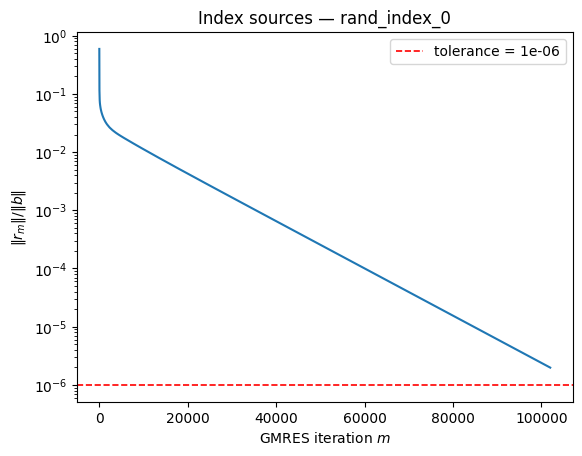

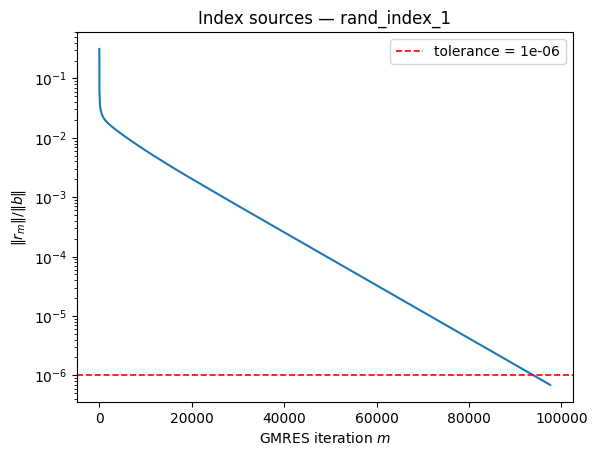

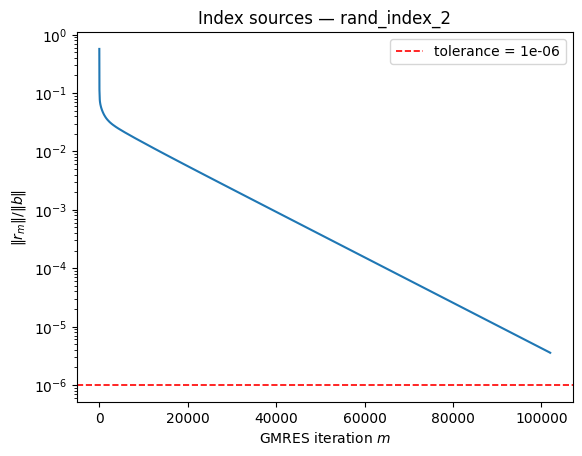

NameError: name 'recordsB' is not defined

In [8]:
# Quick convergence previews (a few cases)
def _preview(records, n=3, title=""):
    for idx, rec in enumerate(records[:n]):
        res = rec["solver_result"]
        ax = plot_residuals(res, tol=gmres_opts.tol)
        if ax is not None:
            name = getattr(rec["load"], "name", f"case_{idx}")
            ax.set_title(f"{title} — {name}")
            ax.set_xlabel(r"GMRES iteration $m$")
            ax.set_ylabel(r"$\|r_m\| / \|b\|$")
            plt.show()

_preview(recordsA, title="Index sources")
_preview(recordsB, title="Continuous sources")

In [ ]:
# %% Batch B — random **continuous** point sources with bilinear deposit
N = 20
batch_cont = [RandomContinuousPointSource(seed=s, interior_margin_cells=1, name=f"rand_cont_{s}") for s in range(N)]

sweepB = SweepConfig(grids=[grid], wavenumbers=[k], loads=batch_cont, discretisations=[disc])
recordsB = list(run_experiment(sweepB, solver_options=gmres_opts))

print("Batch B (continuous):",
      sum(r["solver_result"].converged for r in recordsB), "/", len(recordsB), "converged")


In [ ]:
# %% Quick convergence previews (a few cases)
def _preview(records, n=3, title=""):
    for idx, rec in enumerate(records[:n]):
        res = rec["solver_result"]
        ax = plot_residuals(res, tol=gmres_opts.tol)
        if ax is not None:
            name = getattr(rec["load"], "name", f"case_{idx}")
            ax.set_title(f"{title} — {name}")
            ax.set_xlabel(r"GMRES iteration $m$")
            ax.set_ylabel(r"$\|r_m\| / \|b\|$")
            plt.show()

_preview(recordsA, title="Index sources")
_preview(recordsB, title="Continuous sources")


In [ ]:
# %% Visualize one solution field (real part)
rec = recordsB[0] if recordsB else recordsA[0]
sol = rec["solver_result"].solution
_ = plot_field(sol, grid.shape)
plt.title(f"Re{{u}} — {getattr(rec['load'], 'name', 'example')}")
plt.show()


In [ ]:
# %% Minimal CSV logging without pandas (optional)
import csv, pathlib

out = pathlib.Path("data/experiments/2025-10-22_rhs")
out.mkdir(parents=True, exist_ok=True)

def _write_csv(path, records):
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=[
            "name", "seed", "converged", "iters", "final_res", "meta"
        ])
        writer.writeheader()
        for r in records:
            res = r["solver_result"]
            load = r["load"]
            last = getattr(load, "_last", None)
            writer.writerow({
                "name": getattr(load, "name", type(load).__name__),
                "seed": getattr(load, "seed", None),
                "converged": res.converged,
                "iters": len(res.residuals),
                "final_res": (res.residuals[-1] if res.residuals else None),
                "meta": last,
            })

_write_csv(out / "batch_index.csv", recordsA)
_write_csv(out / "batch_continuous.csv", recordsB)
print("Wrote:", (out / "batch_index.csv").as_posix(), "and", (out / "batch_continuous.csv").as_posix())
